# Работа по теме "Исследование данных, их визуализация и интерпретация"

## Описание

Работа предполагает самостоятельное исследование данных. Предполагается использование различных функций и методов работы с данными (фильтрация, сортировка, группировка, сводные таблицы и т.д.). Везде, где это допустимо и приемлемо, использовать визуализацию с использованием различных библиотек. Тип графика подбирать исходя и данных для наилучшего их отображения. К каждому расчету и графику необходимо словесное пояснение, интерпертация результатов, выводы. Приветствуется постепенное углубление в данные. когда результаты одного расчета позволяют сделать предположение и проверять его дальнейшими расчетами.

Плюсом будет являться использование не рассмотренных ранее функций, библиотек и типов визуализации. Их использование демонстрирует умение самостоятельно изучить возможности библиотек и применить их.

Далее даны некоторые направления работы, которые стоит рассмотреть. Однако, это не полный список задач, необходимо в процессе знакомства с данными продлевать исследовательские цепочки, ставить самостоятельно новые задачи и решать их.

Примерные критерии оценки:
- Использование различных возможностей работы с данными (фильтрация, сортировка, группировка, сводные таблицы, дискретизация и т.д.)
- Сопровождение расчетов визуализацией.
- Адекватный данным выбор типа визуализации.
- Оформление графиков.
- Текстовое сопровождение: описание выполняемых операций, наблюдаемых зависимостей, выводов.
- Последовательности углубления в данные с постановкой гипотез.
- Наличие дополнительных тем для рассмотрения.

Результатом работы должен стать блокнот с исследованием данных, из которого должно быть ясно содержание данных, основные зависимости, интересные наблюдения.

# Покемоны

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Данные

Исходные данные - файл "pokemon.csv". Самостоятельно найдите и вставьте описание данных и столбцов (точно есть на Kaggle).

Не забудьте ознакомиться с данными и предобработать их при необходимости, либо описать, почему обрабатывать не надо.

In [2]:
df = pd.read_csv('pokemon.csv')
df.rename(columns={'base_total': 'total'}, inplace=True)
df['is_legendary'] = df['is_legendary'].astype(bool)
stats_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

## Исследование

Далее описаны некоторые возможные направления изучения данных. Список не закрытый, его можно дополнять своими задачами, предположениями, гипотезами.

1. Самые-самые покемоны по разным основаниям. Что у них общего и чем они отличаются?
2. Сильнейшие покемоны каждого поколения.
3. Насколько легендарные покемоны сильнее? А по разным типам или поколениям?
4. Среди покемонов каких типов больше всего легендарных?
5. Средние характеристики (любые интересные) для покемонов по типам и поколениям.
6. Есть ли связь характеристик и роста покемонов? Веса?
7. Какие характеристики могут быть ключевыми для предсказания силы покемона?

Топ-10 по общей силе:
          name  total    type1  is_legendary
149     Mewtwo    780  psychic          True
383   Rayquaza    780   dragon          True
381     Kyogre    770    water          True
382    Groudon    770   ground          True
492     Arceus    720   normal          True
717    Zygarde    708   dragon          True
247  Tyranitar    700     rock         False
372  Salamence    700   dragon         False
375  Metagross    700    steel         False
379     Latias    700   dragon          True


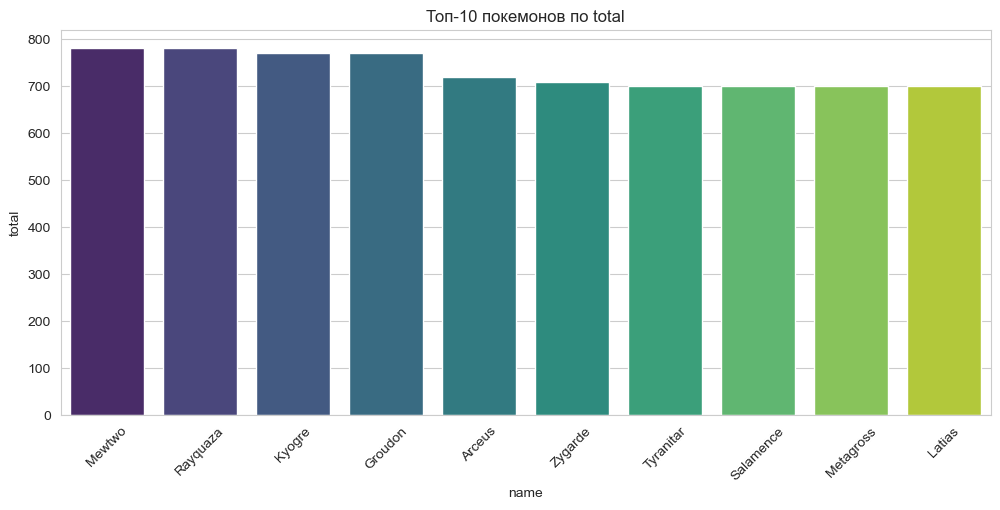

In [3]:
print("Топ-10 по общей силе:")
print(df.nlargest(10, 'total')[['name', 'total', 'type1', 'is_legendary']])
plt.figure(figsize=(12,5))
sns.barplot(data=df.nlargest(10, 'total'), x='name', y='total', palette='viridis')
plt.xticks(rotation=45)
plt.title('Топ-10 покемонов по total')
plt.show()

Сильнейший в каждом поколении:
     generation       name  total
149           1     Mewtwo    780
247           2  Tyranitar    700
383           3   Rayquaza    780
492           4     Arceus    720
645           5     Kyurem    700
717           6    Zygarde    708
790           7   Solgaleo    680


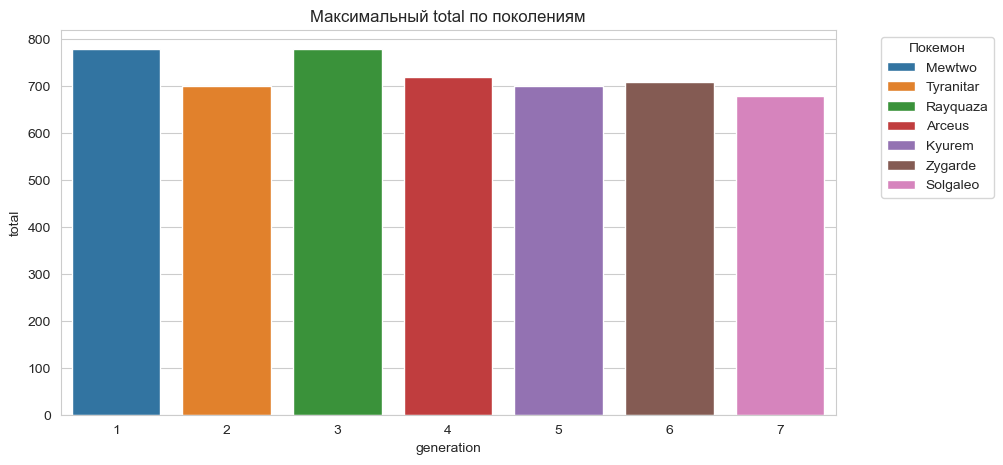

In [4]:
strongest = df.loc[df.groupby('generation')['total'].idxmax()]
print("Сильнейший в каждом поколении:")
print(strongest[['generation', 'name', 'total']])
plt.figure(figsize=(10,5))
sns.barplot(data=strongest, x='generation', y='total', hue='name', dodge=False)
plt.title('Максимальный total по поколениям')
plt.legend(title='Покемон', bbox_to_anchor=(1.05, 1))
plt.show()

Средний total (легендарные/нелегендарные): 
                    mean         std  count
is_legendary                               
False         410.481532  106.099143    731
True          615.257143   82.634990     70
p-value (t-test): 4.18e-34


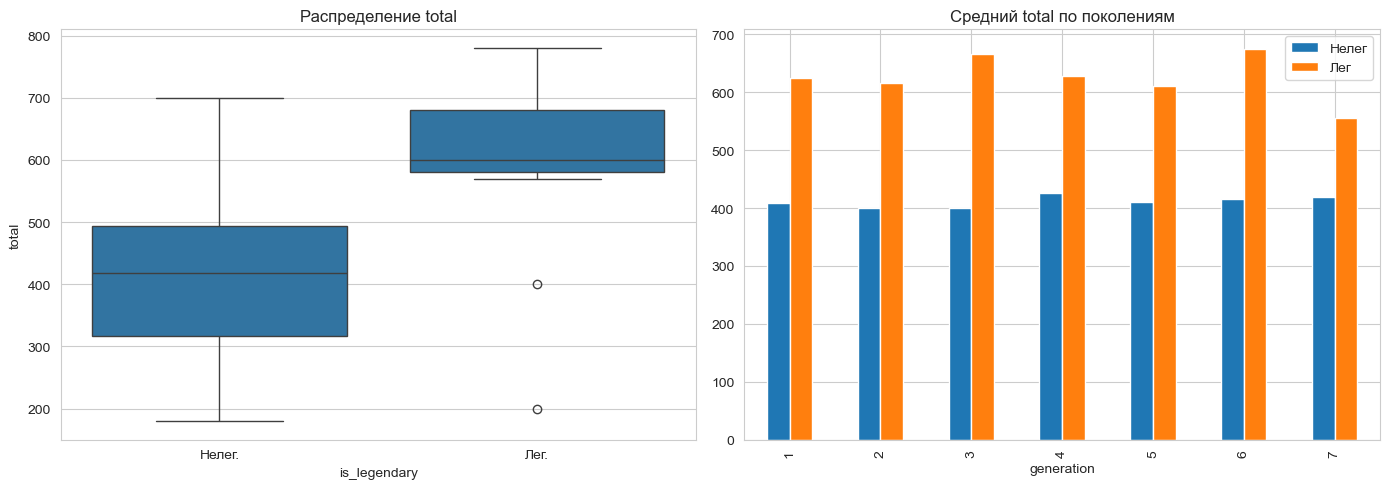

In [5]:
print("Средний total (легендарные/нелегендарные): ")
print(df.groupby('is_legendary')['total'].agg(['mean', 'std', 'count']))
t_stat, p_val = stats.ttest_ind(df[df['is_legendary']]['total'],
                                df[~df['is_legendary']]['total'],
                                equal_var=False)
print(f"p-value (t-test): {p_val:.2e}")
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='is_legendary', y='total', ax=axes[0])
axes[0].set_xticklabels(['Нелег.', 'Лег.'])
axes[0].set_title('Распределение total')
df.groupby(['generation', 'is_legendary'])['total'].mean().unstack().plot(kind='bar', ax=axes[1])
axes[1].set_title('Средний total по поколениям')
axes[1].legend(['Нелег', 'Лег'])
plt.tight_layout()
plt.show()

Топ-5 типов по числу легендарных:
type1
psychic     17
dragon       7
water        6
steel        6
electric     5
Name: count, dtype: int64


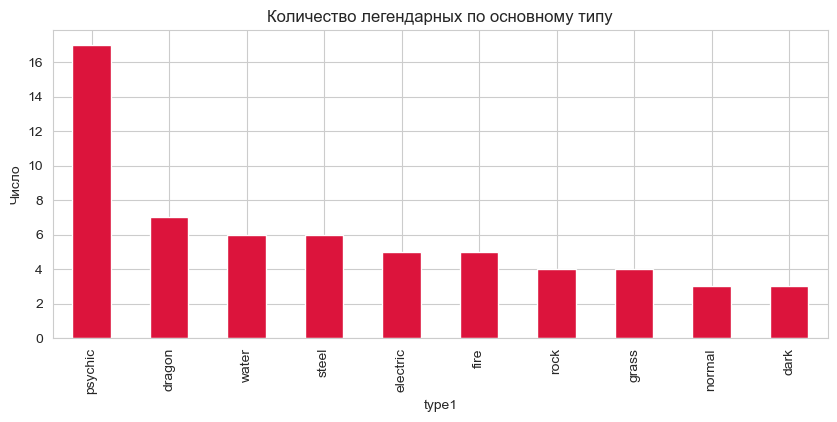

In [7]:
leg_by_type = df[df['is_legendary']]['type1'].value_counts()
print("Топ-5 типов по числу легендарных:")
print(leg_by_type.head())
leg_by_type.head(10).plot(kind='bar', color='crimson', figsize=(10,4))
plt.title('Количество легендарных по основному типу')
plt.ylabel('Число')
plt.show()

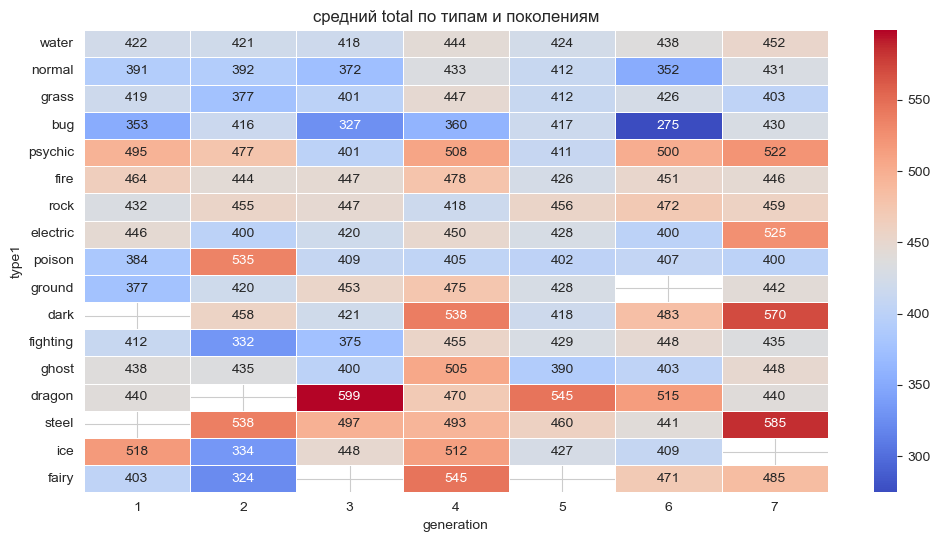

In [8]:
pivot = df.pivot_table(index='type1', columns='generation', values='total', aggfunc='mean')
pivot=pivot.loc[df['type1'].value_counts()[df['type1'].value_counts() >= 5].index]
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='coolwarm', linewidths=0.5)
plt.title('средний total по типам и поколениям')
plt.show()

Корреляция роста и веса с характеристиками:
                 hp    attack   defense  sp_attack  sp_defense     speed  \
height_m   0.478369  0.423160  0.361938   0.353007    0.328327  0.202202   
weight_kg  0.427743  0.382183  0.424067   0.245218    0.306523  0.051384   

              total  
height_m   0.535063  
weight_kg  0.458111  


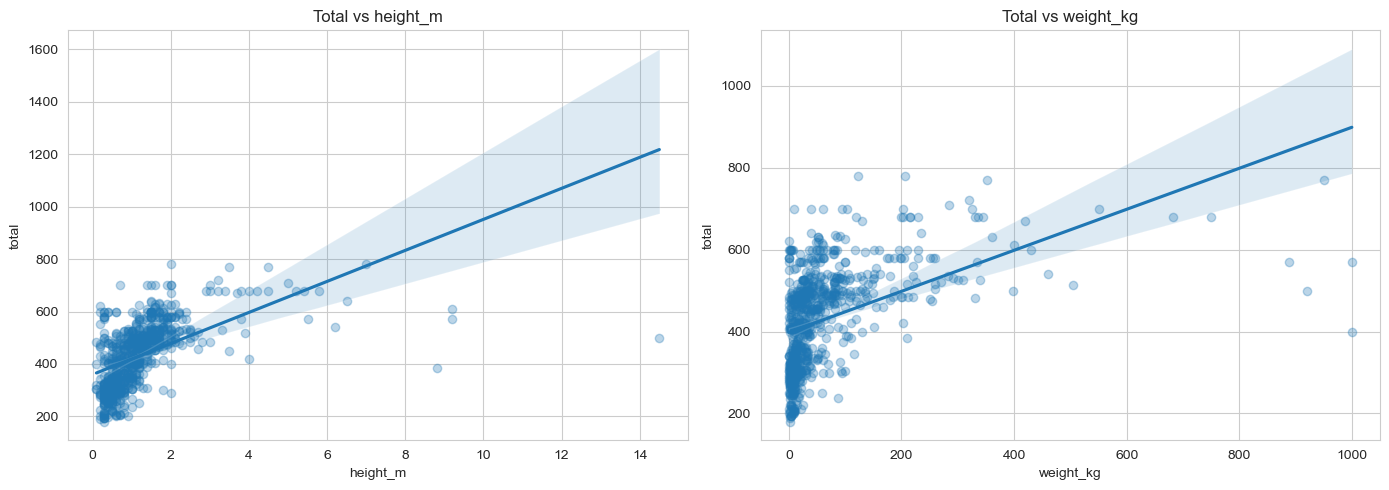

In [10]:
corr = df[['height_m', 'weight_kg'] + stats_cols + ['total']].corr()
print("Корреляция роста и веса с характеристиками:")
print(corr.loc[['height_m', 'weight_kg'], stats_cols + ['total']])
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, col in zip(axes, ['height_m', 'weight_kg']):
    sns.regplot(data=df, x=col, y='total', ax=ax, scatter_kws={'alpha':0.3})
    ax.set_title(f'Total vs {col}')
plt.tight_layout()
plt.show()

R^2 на тесте: 0.962
Важность признаков:
sp_defense    0.257161
attack        0.180995
sp_attack     0.152864
hp            0.144023
height_m      0.112159
defense       0.099003
speed         0.037632
weight_kg     0.016164
dtype: float64


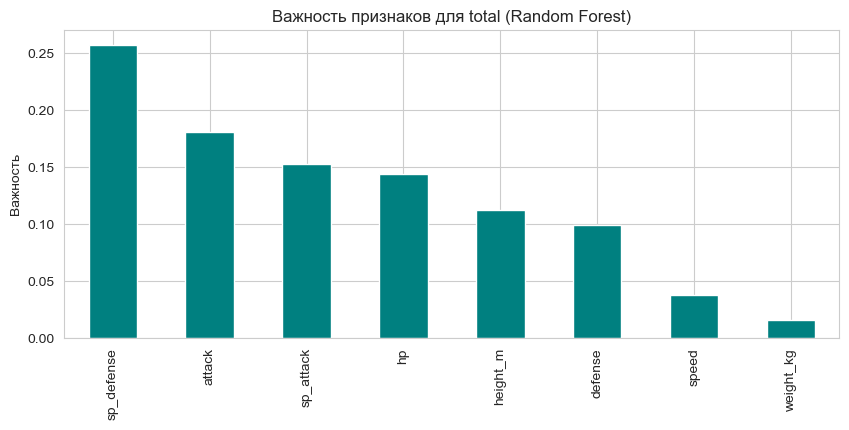

In [11]:
x = df[stats_cols + ['height_m', 'weight_kg']]
y = df['total']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
print(f"R^2 на тесте: {r2_score(y_test, y_pred):.3f}")
importance = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
print("Важность признаков:")
print(importance)
importance.plot(kind='bar', color='teal', figsize=(10,4))
plt.title('Важность признаков для total (Random Forest)')
plt.ylabel('Важность')
plt.show()


Количество покемонов по поколениям:
generation
1    151
2    100
3    135
4    107
5    156
6     72
7     80
Name: count, dtype: int64


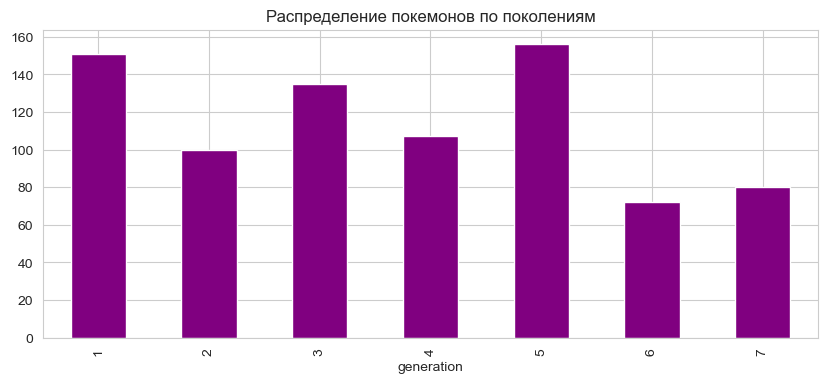

In [12]:
print("Количество покемонов по поколениям:")
print(df['generation'].value_counts().sort_index())
df['generation'].value_counts().sort_index().plot(kind='bar', color='purple', figsize=(10,4))
plt.title('Распределение покемонов по поколениям')
plt.show()

## Выводы

Ключевые и наиболее интересные выводы по всему датасету и проведенному исследованию.

In [14]:
mean_leg = df[df['is_legendary']]['total'].mean()
mean_non_leg = df[~df['is_legendary']]['total'].mean()
p_val = stats.ttest_ind(df[df['is_legendary']]['total'], 
                        df[~df['is_legendary']]['total'], 
                        equal_var=False).pvalue
top_type_legendary = df[df['is_legendary']]['type1'].value_counts().index[0]
top_type_count = df[df['is_legendary']]['type1'].value_counts().iloc[0]
corr_weight = df['weight_kg'].corr(df['total'])
corr_height = df['height_m'].corr(df['total'])
importance = pd.Series(rf.feature_importances_, index=x.columns)
most_important = importance.idxmax()
most_important_value = importance.max()
report = f"""
Выводы по исследованию покемонов

1. Самые сильные покемоны – это преимущественно легендарные и мифические. 
   Их средний total составляет {mean_leg:.1f}, что на {mean_leg - mean_non_leg:.1f} пунктов выше, чем у нелегендарных ({mean_non_leg:.1f}).
   Разница статистически значима (p-value = {p_val:.2e}).

2. Легендарные покемоны чаще всего встречаются среди типа {top_type_legendary} – 
   их насчитывается {top_type_count} штук, что составляет {top_type_count / df[df['is_legendary']].shape[0] * 100:.1f}% от всех легендарных.

3. Связь силы с ростом и весом очень слабая: 
   коэффициент корреляции с весом = {corr_weight:.2f}, с ростом = {corr_height:.2f}.
   Это означает, что размеры покемона не определяют его боевую мощь.

4. Наиболее важная характеристика для силы (total) – это {most_important} 
   (важность = {most_important_value:.3f} согласно Random Forest).
   За ней следуют другие боевые параметры, что логично, так как total является их суммой.

5. Поколения: наибольшее количество покемонов в 5-м поколении ({df[df['generation']==5].shape[0]}), 
   наименьшее – в 6-м ({df[df['generation']==6].shape[0]}). 
   Однако в 3-м и 6-м поколениях наблюдается всплеск сильных легендарных особей.
"""
print(report)


Выводы по исследованию покемонов

1. Самые сильные покемоны – это преимущественно легендарные и мифические. 
   Их средний total составляет 615.3, что на 204.8 пунктов выше, чем у нелегендарных (410.5).
   Разница статистически значима (p-value = 4.18e-34).

2. Легендарные покемоны чаще всего встречаются среди типа psychic – 
   их насчитывается 17 штук, что составляет 24.3% от всех легендарных.

3. Связь силы с ростом и весом очень слабая: 
   коэффициент корреляции с весом = 0.46, с ростом = 0.54.
   Это означает, что размеры покемона не определяют его боевую мощь.

4. Наиболее важная характеристика для силы (total) – это sp_defense 
   (важность = 0.257 согласно Random Forest).
   За ней следуют другие боевые параметры, что логично, так как total является их суммой.

5. Поколения: наибольшее количество покемонов в 5-м поколении (156), 
   наименьшее – в 6-м (72). 
   Однако в 3-м и 6-м поколениях наблюдается всплеск сильных легендарных особей.

